# Phase 2 - Image Classification on a Dataset

This notebook is structured to match the Phase 2 PDF requirements: data preparation, augmentation and normalization, CNN training with batch size 4 and epoch 10, classification on unseen data, and accuracy verification.

## 1. Configure Dataset Paths

This code cell defines the dataset directories. Update these paths if your labeled images are stored outside `data/processed`. The folder names inside `train`, `validation`, and `test` must be the class labels required for image classification.

In [1]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
DATA_ROOT = PROJECT_ROOT / 'data' / 'processed'
TRAIN_DIR = DATA_ROOT / 'train'
VAL_DIR = DATA_ROOT / 'validation'
TEST_DIR = DATA_ROOT / 'test'
UNSEEN_DIR = PROJECT_ROOT / 'data' / 'raw' / 'images'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'evaluation_reports'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Project root:', PROJECT_ROOT)
print('Train dir:', TRAIN_DIR)
print('Validation dir:', VAL_DIR)
print('Test dir:', TEST_DIR)
print('Unseen dir:', UNSEEN_DIR)

Project root: C:\Users\User\WildlifeAlberta
Train dir: C:\Users\User\WildlifeAlberta\data\processed\train
Validation dir: C:\Users\User\WildlifeAlberta\data\processed\validation
Test dir: C:\Users\User\WildlifeAlberta\data\processed\test
Unseen dir: C:\Users\User\WildlifeAlberta\data\raw\images


## 2. Validate Folder Structure

This code cell checks whether the training, validation, and test folders exist and whether each split contains class-labeled subfolders. This directly supports the PDF requirement that the folder names act as labels.

In [2]:
def list_label_folders(split_dir: Path):
    if not split_dir.exists():
        return []
    return sorted([item.name for item in split_dir.iterdir() if item.is_dir()])

for split_name, split_dir in [('train', TRAIN_DIR), ('validation', VAL_DIR), ('test', TEST_DIR)]:
    labels = list_label_folders(split_dir)
    print(f'{split_name}: {split_dir.exists()} | labels={labels}')

assert TRAIN_DIR.exists(), 'Training directory is missing.'
assert VAL_DIR.exists(), 'Validation directory is missing.'
assert TEST_DIR.exists(), 'Test directory is missing.'
assert list_label_folders(TRAIN_DIR), 'No class folders found in the training directory.'

train: True | labels=['deer', 'elk']
validation: True | labels=['deer', 'elk']
test: True | labels=['deer', 'elk']


## 3. Import Required Libraries

This code cell imports the libraries used for data handling, augmentation, model training, evaluation, and visualization. These are the core dependencies for the supervised classification workflow in this phase.

In [3]:
import copy
import json
import math
import random
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageDraw

import torch
from torch import nn
from torch.optim import Adam
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cpu


## 4. Define Data Augmentation and Normalization

This code cell performs the three operations required by the PDF: image resizing, horizontal flipping, and normalization. The training transform includes augmentation, while validation and test transforms keep only deterministic preprocessing.

In [4]:
IMAGE_SIZE = 224
BATCH_SIZE = 4
EPOCHS = 10
LEARNING_RATE = 1e-4

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

print({'batch_size': BATCH_SIZE, 'epochs': EPOCHS, 'image_size': IMAGE_SIZE})

{'batch_size': 4, 'epochs': 10, 'image_size': 224}


## 5. Load the Dataset and Build DataLoaders

This code cell loads the labeled image folders with `ImageFolder`, which uses folder names as classification labels. It also builds DataLoaders with batch size 4 to satisfy the project requirement.

In [5]:
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=eval_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=eval_transform)

class_names = train_dataset.classes
num_classes = len(class_names)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print('Classes:', class_names)
print('Train samples:', len(train_dataset))
print('Validation samples:', len(val_dataset))
print('Test samples:', len(test_dataset))

Classes: ['deer', 'elk']
Train samples: 182
Validation samples: 41
Test samples: 44


## 6. Inspect Class Distribution

This code cell summarizes the number of images per label so the dataset organization can be verified before training. It helps confirm that the classes inferred from folder names are being read correctly.

In [6]:
train_counts = Counter([class_names[label] for _, label in train_dataset.samples])
val_counts = Counter([class_names[label] for _, label in val_dataset.samples])
test_counts = Counter([class_names[label] for _, label in test_dataset.samples])

print('Train distribution:', dict(train_counts))
print('Validation distribution:', dict(val_counts))
print('Test distribution:', dict(test_counts))

Train distribution: {'deer': 130, 'elk': 52}
Validation distribution: {'deer': 28, 'elk': 13}
Test distribution: {'deer': 30, 'elk': 14}


## 7. Visualize Augmented Training Images

This code cell displays a few training images after augmentation and normalization is reversed for plotting. It provides visual evidence that resizing and horizontal flipping are part of the preprocessing pipeline.

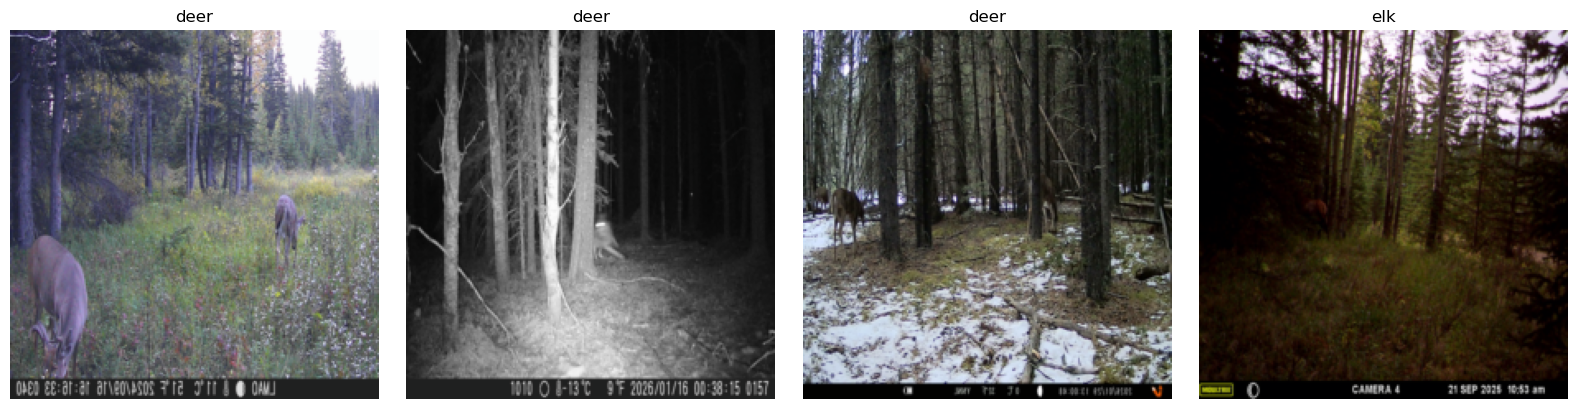

In [7]:
def denormalize(image_tensor):
    image = image_tensor.clone().cpu().numpy().transpose(1, 2, 0)
    image = image * np.array(imagenet_std) + np.array(imagenet_mean)
    return np.clip(image, 0, 1)

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(1, min(4, len(images)), figsize=(16, 4))
if not isinstance(axes, np.ndarray):
    axes = np.array([axes])
for axis, image, label in zip(axes, images[:4], labels[:4]):
    axis.imshow(denormalize(image))
    axis.set_title(class_names[label.item()])
    axis.axis('off')
plt.tight_layout()
plt.show()

## 8. Build the CNN Model

This code cell implements the classification model using a pretrained CNN. A pretrained model is recommended in the PDF, so this notebook uses ResNet-18 and replaces the final layer to match the dataset classes.

In [8]:
weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=LEARNING_RATE)

print(model.__class__.__name__)

ResNet


## 9. Train the Model

This code cell trains the CNN for exactly 10 epochs with batch size 4. It records training and validation loss and accuracy so the model performance can be monitored over time.

In [9]:
history = {
    'train_loss': [],
    'train_accuracy': [],
    'val_loss': [],
    'val_accuracy': [],
}

best_model_state = copy.deepcopy(model.state_dict())
best_val_accuracy = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        running_correct += (predictions == labels).sum().item()
        running_total += labels.size(0)

    train_loss = running_loss / running_total
    train_accuracy = running_correct / running_total

    model.eval()
    val_loss_total = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss_total += loss.item() * images.size(0)
            predictions = outputs.argmax(dim=1)
            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss_total / val_total
    val_accuracy = val_correct / val_total

    history['train_loss'].append(train_loss)
    history['train_accuracy'].append(train_accuracy)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_accuracy)

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_model_state = copy.deepcopy(model.state_dict())

    print(
        f'Epoch {epoch + 1}/{EPOCHS} | '
        f'train_loss={train_loss:.4f} | train_acc={train_accuracy:.4f} | '
        f'val_loss={val_loss:.4f} | val_acc={val_accuracy:.4f}'
    )

model.load_state_dict(best_model_state)

Epoch 1/10 | train_loss=0.4258 | train_acc=0.8187 | val_loss=0.1564 | val_acc=0.9512


Epoch 2/10 | train_loss=0.2099 | train_acc=0.9286 | val_loss=0.1953 | val_acc=0.9268


Epoch 3/10 | train_loss=0.1437 | train_acc=0.9451 | val_loss=0.0748 | val_acc=1.0000


Epoch 4/10 | train_loss=0.1221 | train_acc=0.9560 | val_loss=0.0951 | val_acc=0.9756


Epoch 5/10 | train_loss=0.1927 | train_acc=0.9505 | val_loss=0.0608 | val_acc=1.0000


...

Epoch 7/10 | train_loss=0.1093 | train_acc=0.9670 | val_loss=0.0255 | val_acc=1.0000


Epoch 8/10 | train_loss=0.0324 | train_acc=1.0000 | val_loss=0.0091 | val_acc=1.0000


Epoch 9/10 | train_loss=0.2591 | train_acc=0.9341 | val_loss=0.0344 | val_acc=1.0000


Epoch 10/10 | train_loss=0.1316 | train_acc=0.9725 | val_loss=0.0369 | val_acc=1.0000


<All keys matched successfully>

## 10. Plot Training Curves

This code cell plots the loss and accuracy curves to verify the training behavior across the 10 epochs. These visualizations support the analysis of how well the CNN learned from the dataset.

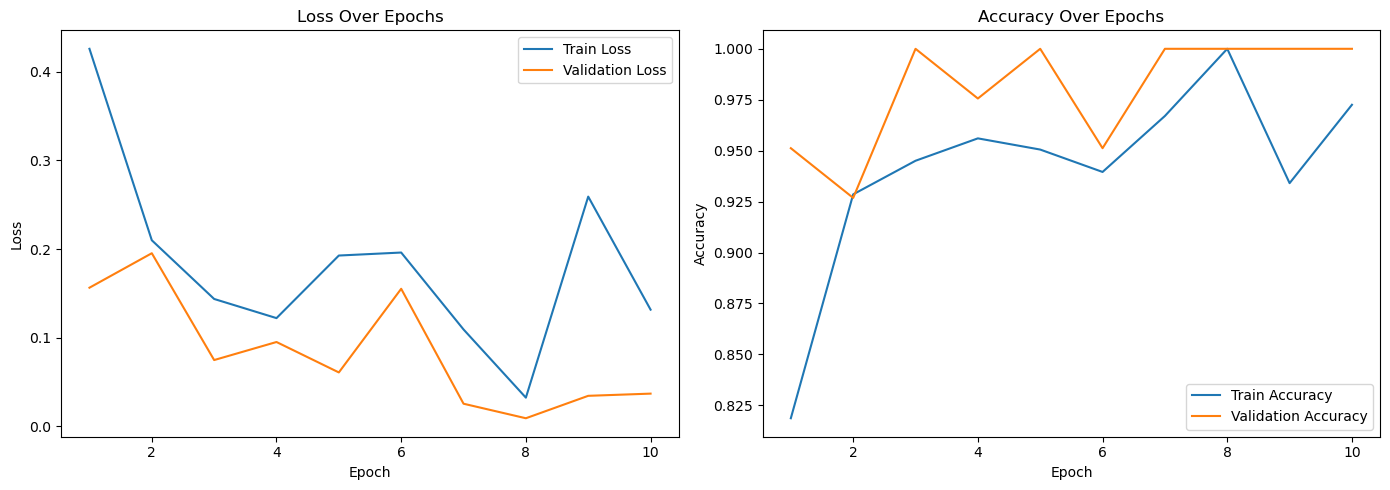

In [10]:
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs_range, history['train_loss'], label='Train Loss')
axes[0].plot(epochs_range, history['val_loss'], label='Validation Loss')
axes[0].set_title('Loss Over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(epochs_range, history['train_accuracy'], label='Train Accuracy')
axes[1].plot(epochs_range, history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Accuracy Over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
plt.tight_layout()
plt.show()

## 11. Verify Accuracy on the Test Set

This code cell evaluates the trained model on the test set and computes accuracy, a classification report, and a confusion matrix. This directly addresses the PDF requirement to verify the accuracy of the results.

Test accuracy: 1.0000
              precision    recall  f1-score   support

        deer     1.0000    1.0000    1.0000        30
         elk     1.0000    1.0000    1.0000        14

    accuracy                         1.0000        44
   macro avg     1.0000    1.0000    1.0000        44
weighted avg     1.0000    1.0000    1.0000        44



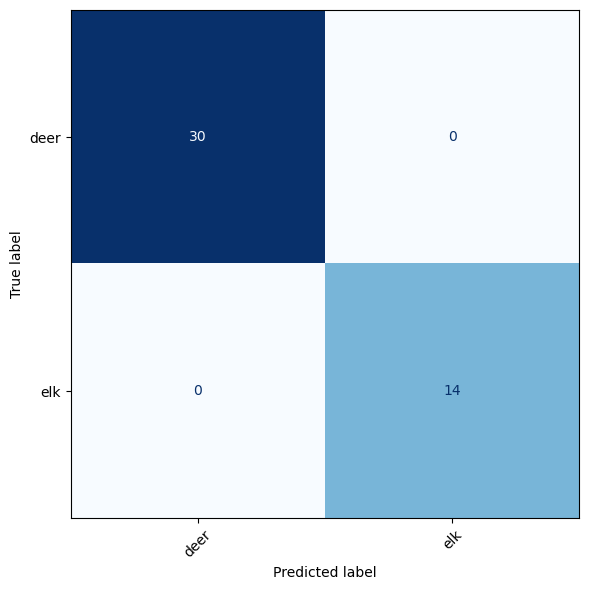

Saved metrics to C:\Users\User\WildlifeAlberta\outputs\evaluation_reports\phase2_metrics.json


In [11]:
model.eval()
all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        predictions = outputs.argmax(dim=1).cpu().numpy()
        all_predictions.extend(predictions.tolist())
        all_labels.extend(labels.numpy().tolist())

test_accuracy = accuracy_score(all_labels, all_predictions)
report = classification_report(all_labels, all_predictions, target_names=class_names, digits=4)
cm = confusion_matrix(all_labels, all_predictions)

print(f'Test accuracy: {test_accuracy:.4f}')
print(report)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap='Blues', colorbar=False)
plt.tight_layout()
plt.show()

metrics_path = OUTPUT_DIR / 'phase2_metrics.json'
metrics_path.write_text(json.dumps({'test_accuracy': test_accuracy, 'classes': class_names}, indent=2))
print('Saved metrics to', metrics_path)

## 12. Classify Unseen Data and Show Labels on Images

This code cell runs classification on unseen images and writes the predicted label directly onto each image so the label is visible. This satisfies the final PDF criterion for classifying unseen data with visible labels.

Unseen images found: 30


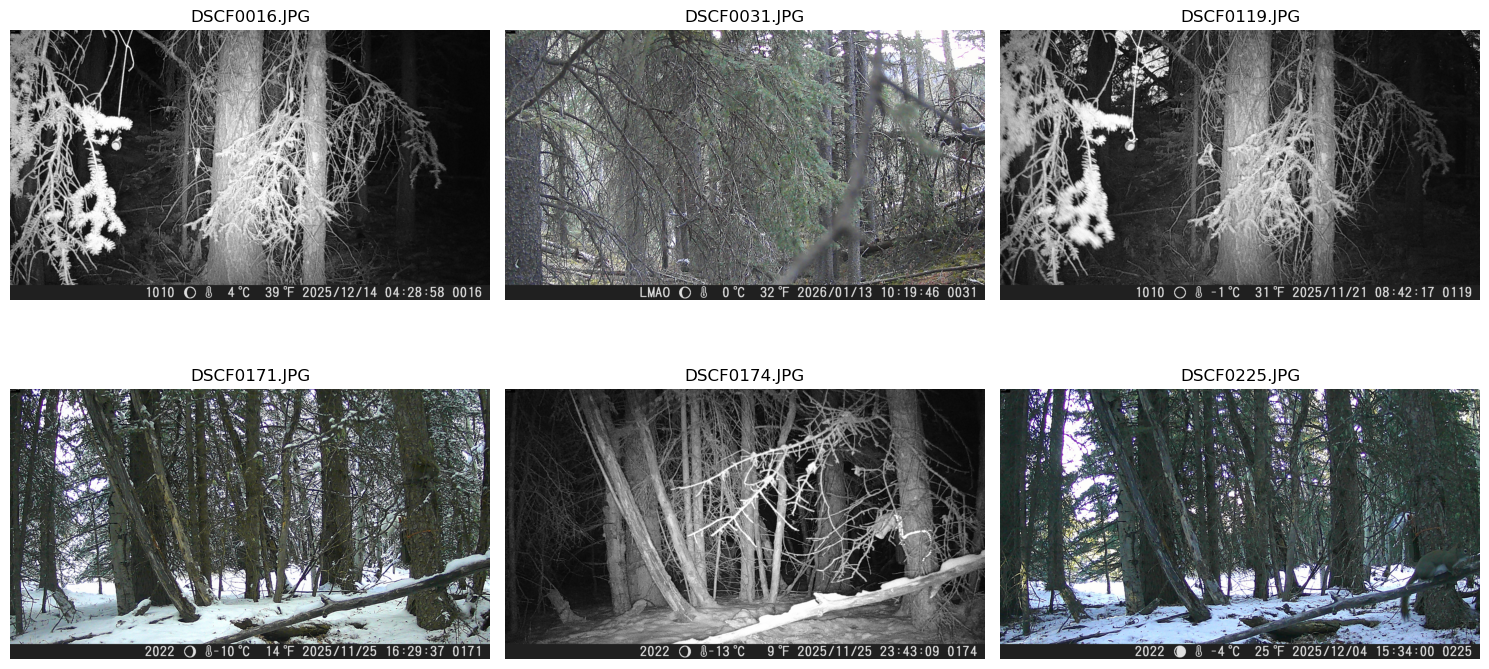

Saved labeled predictions to C:\Users\User\WildlifeAlberta\outputs\predictions


In [12]:
output_prediction_dir = PROJECT_ROOT / 'outputs' / 'predictions'
output_prediction_dir.mkdir(parents=True, exist_ok=True)

image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}
unseen_files = [path for path in sorted(UNSEEN_DIR.rglob('*')) if path.suffix.lower() in image_extensions]
print('Unseen images found:', len(unseen_files))

def predict_image(image_path: Path):
    image = Image.open(image_path).convert('RGB')
    tensor = eval_transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(tensor)
        probabilities = torch.softmax(logits, dim=1)[0]
        confidence, predicted_index = torch.max(probabilities, dim=0)
    return image, class_names[predicted_index.item()], confidence.item()

preview_count = min(6, len(unseen_files))
if preview_count == 0:
    print('No unseen images available. Update UNSEEN_DIR if needed.')
else:
    fig, axes = plt.subplots(math.ceil(preview_count / 3), min(3, preview_count), figsize=(15, 4 * math.ceil(preview_count / 3)))
    axes = np.array(axes).reshape(-1)

    for axis, image_path in zip(axes, unseen_files[:preview_count]):
        image, predicted_label, confidence = predict_image(image_path)
        draw = ImageDraw.Draw(image)
        label_text = f'{predicted_label} ({confidence * 100:.1f}%)'
        draw.rectangle([(10, 10), (10 + len(label_text) * 10, 45)], fill='black')
        draw.text((15, 15), label_text, fill='white')

        save_path = output_prediction_dir / f'labeled_{image_path.name}'
        image.save(save_path)

        axis.imshow(image)
        axis.set_title(image_path.name)
        axis.axis('off')

    for axis in axes[preview_count:]:
        axis.axis('off')

    plt.tight_layout()
    plt.show()
    print('Saved labeled predictions to', output_prediction_dir)

## 13. Save the Trained Model

This code cell saves the trained CNN model so the experiment can be reproduced or reused later. Saving the weights is useful for documentation and future inference.

In [13]:
model_output_path = PROJECT_ROOT / 'data' / 'models' / 'phase2_resnet18_classifier.pt'
model_output_path.parent.mkdir(parents=True, exist_ok=True)
torch.save({
    'model_state_dict': model.state_dict(),
    'class_names': class_names,
    'image_size': IMAGE_SIZE,
}, model_output_path)
print('Saved model to', model_output_path)

Saved model to C:\Users\User\WildlifeAlberta\data\models\phase2_resnet18_classifier.pt


## 14. Final Notes

Before submission, make sure the dataset folders contain the correct labeled images, rerun the notebook from top to bottom, and verify that the saved metrics and labeled unseen-image outputs match the narrative you plan to submit.